# Porsche Taycan Market Analysis

### How this notebook selects the best car

Buying a used Porsche Taycan is tricky because the Turkish market is full of noise: gallery listings with hidden damage histories, suspiciously cheap cars that turn out to have heavy accident records, and overpriced cars coasting on a fancy ad title. This notebook cuts through that by applying a structured, multi-stage filtering and scoring pipeline. First, it **hard-disqualifies** any listing with a heavy damage record ("Agir Hasar"), 3 or more changed body parts, or a 2023+ car with any changed parts at all — because on a Porsche, structural bodywork is a dealbreaker, not a negotiation point. Next, it computes **derived metrics** that the raw listing data doesn't give you: kilometers per year (usage intensity), a normalized damage severity score, whether the car is truly "hatasiz" (zero bodywork), and whether it came from an authorized Porsche/Dogus dealer. Then it ranks every surviving listing with a **composite value score** that weighs price competitiveness within its model/year group (25%), mileage relative to age (20%), damage severity (20%), equipment level (10%), and depreciation resistance based on the pre-facelift vs facelift generation split (25%) — with bonuses for clean cars, dealer provenance, and premium trims like GTS and Turbo S that hold resale value better. Finally, it produces a unified **Top 15 Candidates** table where each car has auto-generated reasoning (citing specific numbers like "Flagship Turbo S at 18% below market median · Barely driven · Zero damage + dealer origin") and buyer-profile tags (**SAFE** for zero-risk picks, **VALUE** for best price-performance), plus a ready-to-paste AI prompt using the same 15 cars with their reasoning so you can get a second opinion from any LLM.

---

*Run `python run_scraper.py` first to populate the database, then execute all cells top-to-bottom.*

In [73]:
import sqlite3
import re
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML

## Section 1: Data Loading

Loads the latest scrape run from the SQLite database into pandas DataFrames. Station wagons (Cross Turismo variants) are excluded since we're only interested in sedan/coupe body styles. This cell provides a quick overview of what we're working with: total listings, price range, and how many of each model variant are available. If the numbers look off, re-run the scraper before continuing.

In [ ]:
conn = sqlite3.connect("taycan.db")

# Get latest scrape run
run_id = pd.read_sql("SELECT MAX(id) as id FROM scrape_runs", conn).iloc[0]["id"]
print(f"Using scrape run #{int(run_id)}")

# Diagnostic: active vs total listings
_active_total = pd.read_sql(f"""
    SELECT
        COUNT(*) as total,
        SUM(CASE WHEN is_active = 1 THEN 1 ELSE 0 END) as active
    FROM listings WHERE scrape_run_id = {int(run_id)} AND detail_scraped = 1
""", conn).iloc[0]
print(f"Active listings: {int(_active_total['active'])} / {int(_active_total['total'])} total")

# Load listings (exclude station wagons / Cross Turismo, only active)
df = pd.read_sql(f"""
    SELECT * FROM listings
    WHERE scrape_run_id = {int(run_id)} AND detail_scraped = 1
    AND is_active = 1
    AND COALESCE(body_type, '') != 'Station Wagon'
""", conn)

# Load damage parts
df_damage = pd.read_sql(f"""
    SELECT dp.* FROM damage_parts dp
    JOIN listings l ON dp.listing_id = l.id
    WHERE l.scrape_run_id = {int(run_id)}
    AND l.is_active = 1
    AND COALESCE(l.body_type, '') != 'Station Wagon'
""", conn)

# Load features
df_features = pd.read_sql(f"""
    SELECT f.* FROM features f
    JOIN listings l ON f.listing_id = l.id
    WHERE l.scrape_run_id = {int(run_id)}
    AND l.is_active = 1
    AND COALESCE(l.body_type, '') != 'Station Wagon'
""", conn)

print(f"\nTotal listings: {len(df)}")
print(f"Price range: {df['price'].min():,.0f} - {df['price'].max():,.0f} TL")
print(f"\nModel distribution:")
print(df['model'].value_counts().to_string())

# --- Parse Turkish listing dates into proper dates ---
TURKISH_MONTHS = {
    "Ocak": 1, "Şubat": 2, "Mart": 3, "Nisan": 4,
    "Mayıs": 5, "Haziran": 6, "Temmuz": 7, "Ağustos": 8,
    "Eylül": 9, "Ekim": 10, "Kasım": 11, "Aralık": 12
}

_scrape_date = pd.to_datetime(
    pd.read_sql(f"SELECT started_at FROM scrape_runs WHERE id = {int(run_id)}", conn).iloc[0, 0]
).date()

def _parse_listing_date(date_str, ref_date):
    """Parse '06 Şubat' into datetime.date, inferring year from scrape date."""
    if not date_str or not isinstance(date_str, str):
        return None
    try:
        parts = date_str.strip().split()
        day, month = int(parts[0]), TURKISH_MONTHS.get(parts[1])
        if month is None:
            return None
        d = pd.Timestamp(year=ref_date.year, month=month, day=day).date()
        return d.replace(year=ref_date.year - 1) if d > ref_date else d
    except (ValueError, IndexError):
        return None

df["listing_date_parsed"] = df["listing_date"].apply(lambda x: _parse_listing_date(x, _scrape_date))

# Save unfiltered copies for date range filtering
_df_raw = df.copy()
_df_damage_raw = df_damage.copy()
_df_features_raw = df_features.copy()

_parsed_dates = sorted(df["listing_date_parsed"].dropna().unique())
if _parsed_dates:
    print(f"\nListing dates span: {_parsed_dates[0]} to {_parsed_dates[-1]}")

### Date Range Filter

Filters listings by their posting date on sahibinden.com. Useful when older listings have stale prices or may already be sold. Listings with unparseable dates are always kept.

**After adjusting the slider, re-run this cell and all cells below (Cell > Run All Below) to update the analysis.**

In [ ]:
# Date range filter — adjust the slider, then re-run this cell + all cells below
_valid_dates = sorted(_df_raw["listing_date_parsed"].dropna().unique())

if _valid_dates:
    _date_range = pd.date_range(_valid_dates[0], _valid_dates[-1], freq='D')
    _slider_options = [(d.strftime('%d %b %Y'), d.date()) for d in _date_range]

    date_range_slider = widgets.SelectionRangeSlider(
        options=_slider_options,
        index=(0, len(_slider_options) - 1),
        description='Listing dates:',
        layout=widgets.Layout(width='90%'),
        style={'description_width': 'initial'},
        continuous_update=False
    )

    _filter_info = widgets.Output()
    _unparsed_count = int(_df_raw["listing_date_parsed"].isna().sum())

    def _preview_filter(change=None):
        _filter_info.clear_output(wait=True)
        with _filter_info:
            s, e = date_range_slider.value
            m = _df_raw["listing_date_parsed"].between(s, e)
            if _unparsed_count:
                m = m | _df_raw["listing_date_parsed"].isna()
            n_in, n_out = int(m.sum()), int((~m).sum())
            print(f"  {n_in} listings in range, {n_out} excluded  ({(e - s).days + 1}-day window)")
            if _unparsed_count:
                print(f"  ({_unparsed_count} with unparseable dates always included)")

    date_range_slider.observe(_preview_filter, names='value')
    display(date_range_slider, _filter_info)
    _preview_filter()

    # Apply filter based on current slider position
    _start, _end = date_range_slider.value
    _date_mask = _df_raw["listing_date_parsed"].between(_start, _end) | _df_raw["listing_date_parsed"].isna()
    df = _df_raw[_date_mask].copy()
    _kept_ids = set(df["id"])
    df_damage = _df_damage_raw[_df_damage_raw["listing_id"].isin(_kept_ids)].copy()
    df_features = _df_features_raw[_df_features_raw["listing_id"].isin(_kept_ids)].copy()

    _n_removed = len(_df_raw) - len(df)
    if _n_removed > 0:
        print(f"\nFilter applied: {_n_removed} listings removed, {len(df)} remaining")
        print(f"Filtered price range: {df['price'].min():,.0f} - {df['price'].max():,.0f} TL")
    else:
        print(f"\nAll {len(df)} listings are within the selected range")
else:
    print("No parseable listing dates found — no date filtering available.")

## Section 2: Disqualification & Filtering

Hard-filters listings that should never appear in recommendations. Cars with heavy damage records, 3+ changed body parts, or suspiciously damaged new cars (2023+ with any changed parts) are separated into a disqualified pool. This step ensures all downstream analysis — value scores, top picks, AI recommendations — only considers cars worth actually buying. The disqualified table is shown for reference so you can see what was removed and why.

In [75]:
# --- Disqualification thresholds (edit these) ---
CURRENT_YEAR = 2026
DISQUALIFY_HEAVY_DAMAGE = True       # Ağır hasar kaydı = Evet
DISQUALIFY_CHANGED_THRESHOLD = 3     # >= this many changed parts
DISQUALIFY_NEW_CAR_CHANGED = True    # year >= 2023 AND changed_count >= 1
MAX_KM_PER_YEAR = 25_000             # flag (not disqualify) high-usage cars

# --- Apply disqualification ---
df_all = df.copy()  # keep full dataset for reference

changed = df["damage_changed_count"].fillna(0)
mask_heavy = df["heavy_damage_record"] == "Evet"
mask_changed = changed >= DISQUALIFY_CHANGED_THRESHOLD
mask_new_changed = (df["year"] >= 2023) & (changed >= 1)

# Build reasons per row
reasons = []
for idx in df.index:
    r = []
    if DISQUALIFY_HEAVY_DAMAGE and mask_heavy[idx]:
        r.append("Heavy damage record")
    if mask_changed[idx]:
        r.append(f"{int(changed[idx])} changed parts (>= {DISQUALIFY_CHANGED_THRESHOLD})")
    if DISQUALIFY_NEW_CAR_CHANGED and mask_new_changed[idx] and not mask_changed[idx]:
        r.append(f"New car ({df.loc[idx, 'year']}) with {int(changed[idx])} changed part(s)")
    reasons.append("; ".join(r) if r else None)

df["dq_reason"] = reasons
disqualified_mask = df["dq_reason"].notna()

df_disqualified = df[disqualified_mask].copy()
df = df[~disqualified_mask].copy()

# Summary
print(f"Disqualified: {len(df_disqualified)} listings")
print(f"Eligible: {len(df)} listings\n")

if not df_disqualified.empty:
    dq_display = df_disqualified[
        ["sahibinden_id", "model", "year", "km", "price",
         "heavy_damage_record", "damage_changed_count", "dq_reason"]
    ].sort_values("price").reset_index(drop=True)
    dq_display.index += 1
    print("Disqualified listings:")
    display(dq_display.style.format({"price": "{:,.0f}", "km": "{:,.0f}"}))

Disqualified: 13 listings
Eligible: 253 listings

Disqualified listings:


,sahibinden_id,model,year,km,price,heavy_damage_record,damage_changed_count,dq_reason
1,1274117597,4S,2021,"82,000","5,150,000",Evet,2,Heavy damage record
2,1297817765,4S,2020,"90,000","5,150,000",Hayır,3,3 changed parts (>= 3)
3,1292842367,4S,2020,"98,000","5,350,000",Evet,0,Heavy damage record
4,1292605900,4S,2020,"59,000","5,490,000",Evet,0,Heavy damage record
5,1294283285,4S,2020,"44,000","5,500,000",Evet,0,Heavy damage record
6,1291097455,4S,2021,"79,000","5,850,000",Evet,0,Heavy damage record
7,1270843906,Turbo,2020,"71,000","5,950,000",Evet,0,Heavy damage record
8,1284383604,4S,2020,"35,000","6,100,000",Evet,2,Heavy damage record
9,1254076007,Turbo S,2020,"73,500","6,500,000",Evet,1,Heavy damage record
10,1292274477,Turbo,2020,"34,000","6,500,000",Evet,0,Heavy damage record


## Section 3: Derived Metrics & Risk Flags

Computes per-listing metrics that aren't in the raw data but are essential for informed comparison. km_per_year reveals true usage intensity (a 2020 car with 30k km is babied; a 2023 with 90k km is a taxi). damage_severity normalizes the bodywork situation to a 0-1 scale. is_clean and is_bayi flag the two strongest trust signals in the Turkish used car market: zero bodywork and authorized dealer origin. Risk flags highlight listings that passed the hard filters but still deserve extra scrutiny.

In [76]:
# --- Derived metrics ---
df["car_age"] = CURRENT_YEAR - df["year"]
df["km_per_year"] = df.apply(
    lambda r: r["km"] / max(r["car_age"], 1) if r["km"] is not None else None, axis=1
)
df["price_per_km"] = df.apply(
    lambda r: r["price"] / max(r["km"], 1) if r["km"] and r["km"] > 0 else None, axis=1
)

# Damage severity: normalized 0-1 scale
max_possible_penalty = 14 * 3  # 14 body parts, worst case all changed
df["damage_severity"] = (
    df["damage_changed_count"].fillna(0) * 3 +
    df["damage_painted_count"].fillna(0) * 1.5 +
    df["damage_local_painted_count"].fillna(0) * 1
) / max_possible_penalty

df["is_clean"] = (
    (df["damage_changed_count"].fillna(0) == 0) &
    (df["damage_painted_count"].fillna(0) == 0) &
    (df["damage_local_painted_count"].fillna(0) == 0)
)

# Bayi (authorized dealer) detection from title + description
def detect_bayi(row):
    text = f"{row.get('title', '') or ''} {row.get('description', '') or ''}".lower()
    return bool(re.search(r"\bbayi\b|\bbayii\b|\bdoğuş\b|\bdogus\b", text))

df["is_bayi"] = df.apply(detect_bayi, axis=1)

# --- Risk flags ---
df["risk_high_km"] = df["km_per_year"].fillna(0) > MAX_KM_PER_YEAR
df["risk_many_painted"] = df["damage_painted_count"].fillna(0) >= 2
df["risk_gallery_unknown"] = (
    (df["seller_type"] == "Galeriden") &
    (df["heavy_damage_record"].isna() | (df["heavy_damage_record"] == ""))
)

# Summary
clean_count = df["is_clean"].sum()
bayi_count = df["is_bayi"].sum()
risk_km = df["risk_high_km"].sum()
risk_paint = df["risk_many_painted"].sum()
risk_gallery = df["risk_gallery_unknown"].sum()

print(f"Derived metrics computed for {len(df)} eligible listings:")
print(f"  Clean (hatasız): {clean_count} ({clean_count/len(df)*100:.0f}%)")
print(f"  Bayi çıkışlı: {bayi_count} ({bayi_count/len(df)*100:.0f}%)")
print(f"\nRisk flags:")
print(f"  High km/year (>{MAX_KM_PER_YEAR:,}): {risk_km}")
print(f"  Many painted (>=2): {risk_paint}")
print(f"  Gallery w/unknown damage record: {risk_gallery}")

Derived metrics computed for 253 eligible listings:
  Clean (hatasız): 222 (88%)
  Bayi çıkışlı: 151 (60%)

Risk flags:
  High km/year (>25,000): 2
  Many painted (>=2): 8
  Gallery w/unknown damage record: 0


## Section 4: Price Analysis

Breaks down the market by price. The histogram shows where most listings cluster for each model variant — useful for spotting if a listing is priced above or below the pack. The price-vs-year and price-vs-km scatter plots reveal how much each factor drives pricing. The price-per-km box plot highlights which models give you the most car for the money. Use this section to calibrate your budget expectations and identify outliers worth investigating.

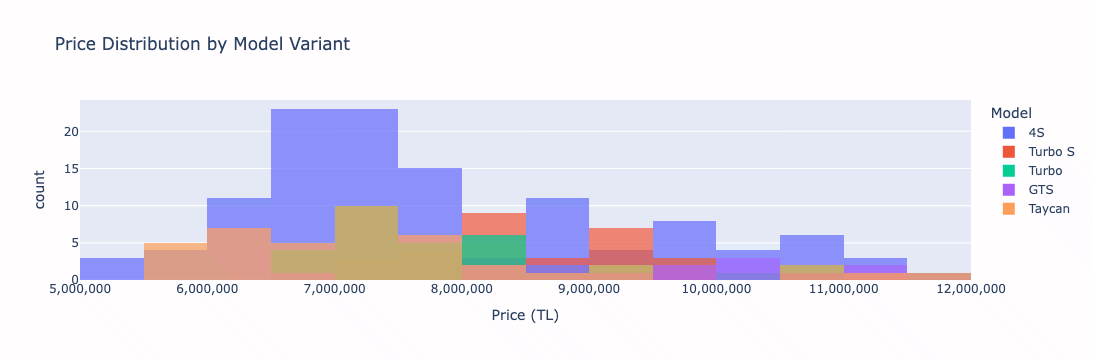

In [77]:
# Price distribution by model variant (capped at 12M TL)
fig = px.histogram(
    df[df["price"] <= 12_000_000], x="price", color="model",
    title="Price Distribution by Model Variant",
    labels={"price": "Price (TL)", "model": "Model"},
    nbins=30, barmode="overlay", opacity=0.7
)
fig.update_layout(xaxis_tickformat=",.0f")
fig.show()

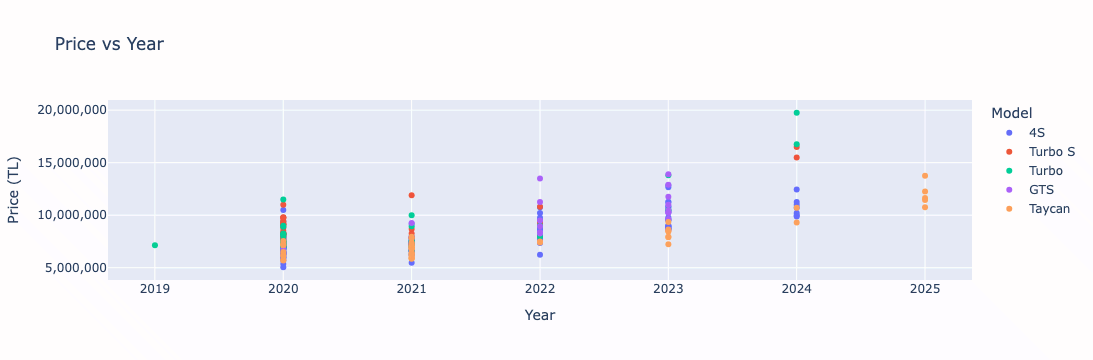

In [78]:
# Price vs Year scatter
fig = px.scatter(
    df, x="year", y="price", color="model",
    hover_data=["km", "title", "sahibinden_id"],
    title="Price vs Year",
    labels={"year": "Year", "price": "Price (TL)", "model": "Model"}
)
fig.update_layout(yaxis_tickformat=",.0f")
fig.show()

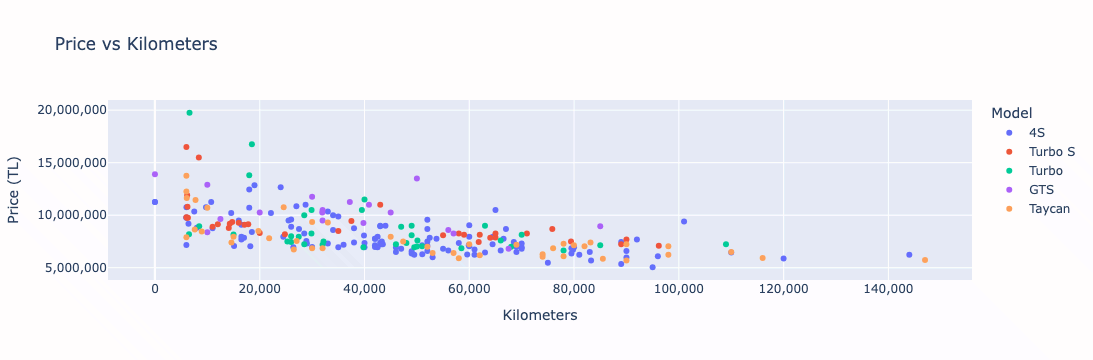

In [79]:
# Price vs KM scatter
fig = px.scatter(
    df, x="km", y="price", color="model",
    hover_data=["year", "title", "sahibinden_id"],
    title="Price vs Kilometers",
    labels={"km": "Kilometers", "price": "Price (TL)", "model": "Model"}
)
fig.update_layout(xaxis_tickformat=",.0f", yaxis_tickformat=",.0f")
fig.show()

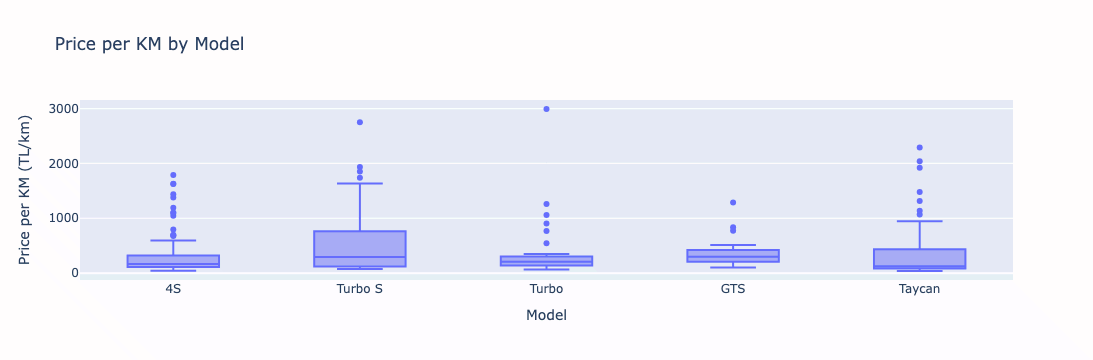

In [80]:
# Price per km box plot (price_per_km already computed in Section 3)
fig = px.box(
    df.dropna(subset=["price_per_km"]),
    x="model", y="price_per_km",
    title="Price per KM by Model",
    labels={"model": "Model", "price_per_km": "Price per KM (TL/km)"}
)
fig.show()

## Section 5: Value Score

Ranks every listing with a single 0-100 composite score combining five factors: price competitiveness within its model/year group (25%), mileage relative to age (20%), body damage severity (20%), equipment/feature count (10%), and depreciation resistance based on model year (25%). After the base score is computed, three adjustments are applied: a trim multiplier (GTS/Turbo S score higher for resale liquidity), a hatasız (damage-free) bonus, and a bayi çıkışlı (authorized dealer) bonus. The decomposed score table shows exactly why each car ranked the way it did.

In [81]:
def calculate_value_score(df, df_features):
    scores = pd.DataFrame(index=df.index)
    current_year = CURRENT_YEAR

    # 1. Price z-score within model/year group (lower price = better value)
    df["price_zscore"] = df.groupby(["model", "year"])["price"].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
    scores["price_score"] = -df["price_zscore"]

    # 2. KM score: expected km vs actual (fewer km for age = better)
    df["expected_km"] = df["car_age"] * 15000
    df["km_ratio"] = df.apply(
        lambda r: r["km"] / r["expected_km"] if r["expected_km"] > 0 and r["km"] is not None else 1,
        axis=1
    )
    scores["km_score"] = 1 - df["km_ratio"].clip(0, 2) / 2

    # 3. Damage penalty
    df["damage_penalty"] = (
        df["damage_changed_count"].fillna(0) * 3 +
        df["damage_painted_count"].fillna(0) * 1.5 +
        df["damage_local_painted_count"].fillna(0) * 1
    )
    max_penalty = df["damage_penalty"].max() if df["damage_penalty"].max() > 0 else 1
    scores["damage_score"] = 1 - (df["damage_penalty"] / max_penalty)

    # 4. Feature bonus
    feature_counts = df_features[df_features["is_present"] == 1].groupby("listing_id").size()
    df["feature_count"] = df["id"].map(feature_counts).fillna(0)
    max_features = df["feature_count"].max() if df["feature_count"].max() > 0 else 1
    scores["feature_score"] = df["feature_count"] / max_features

    # 5. Depreciation resistance score
    def depr_score(row):
        year = row["year"]
        if year >= 2024:
            return 1.0   # Facelift — best depreciation resistance
        elif year == 2023:
            return 0.6   # Last pre-facelift, still relatively recent
        elif year == 2022:
            return 0.4   # Mid-life pre-facelift
        elif year == 2021:
            return 0.25  # Already depreciated significantly
        else:
            return 0.1   # 2019-2020: oldest, most depreciation risk remaining

    scores["depr_score"] = df.apply(depr_score, axis=1)

    # Composite score (weighted)
    df["value_score_raw"] = (
        scores["price_score"] * 0.25 +
        scores["km_score"] * 0.20 +
        scores["damage_score"] * 0.20 +
        scores["feature_score"] * 0.10 +
        scores["depr_score"] * 0.25
    )

    # Normalize base score to 0-100
    vmin, vmax = df["value_score_raw"].min(), df["value_score_raw"].max()
    if vmax > vmin:
        df["value_score_raw"] = ((df["value_score_raw"] - vmin) / (vmax - vmin) * 100).round(1)
    else:
        df["value_score_raw"] = 50.0

    # --- New adjustments ---

    # Trim multiplier (applied to base score)
    trim_mult = {"GTS": 1.10, "Turbo S": 1.08, "Turbo": 1.05, "4S": 1.0, "Taycan": 0.95}
    df["trim_mult"] = df["model"].map(trim_mult).fillna(1.0)

    # Hatasız bonus (+5 for clean cars)
    df["clean_bonus"] = df["is_clean"].astype(float) * 5.0

    # Bayi bonus (+3 for dealer origin)
    df["bayi_bonus"] = df["is_bayi"].astype(float) * 3.0

    # Final score
    df["value_score"] = (df["value_score_raw"] * df["trim_mult"] + df["clean_bonus"] + df["bayi_bonus"]).round(1)

    # Re-normalize to 0-100
    vmin2, vmax2 = df["value_score"].min(), df["value_score"].max()
    if vmax2 > vmin2:
        df["value_score"] = ((df["value_score"] - vmin2) / (vmax2 - vmin2) * 100).round(1)
    else:
        df["value_score"] = 50.0

    # Store component scores for decomposition
    for col in ["price_score", "km_score", "damage_score", "feature_score", "depr_score"]:
        df[col] = scores[col]

    return df

df = calculate_value_score(df, df_features)

# Decomposed score table — top 15
top15 = df.nlargest(15, "value_score")
decomp_cols = ["sahibinden_id", "model", "year",
               "price_score", "km_score", "damage_score", "feature_score", "depr_score",
               "trim_mult", "clean_bonus", "bayi_bonus", "value_score"]
decomp = top15[decomp_cols].reset_index(drop=True)
decomp.index += 1

print("Top 15 — Decomposed Value Scores:")
display(decomp.style.format({
    "price_score": "{:.2f}", "km_score": "{:.2f}", "damage_score": "{:.2f}",
    "feature_score": "{:.2f}", "depr_score": "{:.2f}", "trim_mult": "{:.2f}",
    "clean_bonus": "{:.1f}", "bayi_bonus": "{:.1f}", "value_score": "{:.1f}"
}).background_gradient(subset=["value_score"], cmap="RdYlGn"))

Top 15 — Decomposed Value Scores:


,sahibinden_id,model,year,price_score,km_score,damage_score,feature_score,depr_score,trim_mult,clean_bonus,bayi_bonus,value_score
1,1294179544,GTS,2023,1.47,0.38,1.00,0.75,0.60,1.10,5.0,3.0,100.0
2,1285513217,GTS,2023,0.80,0.86,1.00,0.88,0.60,1.10,5.0,3.0,95.8
3,1285887345,4S,2021,2.37,0.50,0.83,0.91,0.25,1.00,0.0,3.0,94.9
4,1281103381,Turbo S,2024,0.71,0.86,1.00,0.00,1.00,1.08,5.0,0.0,90.3
5,1295622327,4S,2020,2.11,0.47,1.00,0.00,0.10,1.00,5.0,3.0,89.5
6,1285704385,Turbo,2024,0.71,0.69,1.00,0.00,1.00,1.05,5.0,3.0,88.4
7,1262362687,GTS,2022,0.78,0.92,1.00,0.53,0.40,1.10,5.0,0.0,87.3
8,1298727668,Turbo S,2022,0.71,0.87,1.00,0.56,0.40,1.08,5.0,3.0,86.9
9,1286633466,Turbo S,2020,1.74,0.47,0.83,0.56,0.10,1.08,0.0,3.0,86.8
10,1232719997,GTS,2022,0.84,0.53,1.00,0.53,0.40,1.10,5.0,3.0,85.9


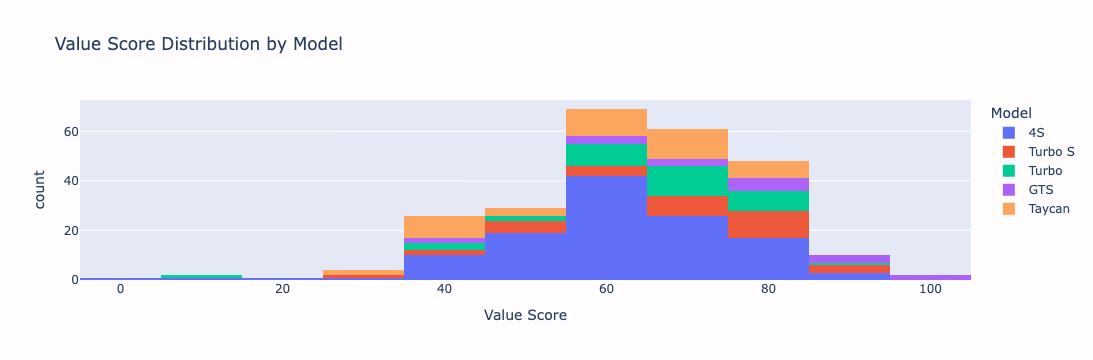

In [82]:
# Value score distribution
fig = px.histogram(
    df, x="value_score", color="model", nbins=20,
    title="Value Score Distribution by Model",
    labels={"value_score": "Value Score", "model": "Model"}
)
fig.show()

## Section 6: Damage Analysis

Shows the physical condition landscape across all eligible listings. The pie chart gives an overall ratio of original vs damaged parts. The box plot reveals how much damage categories (clean, paint only, changed parts) affect pricing — use this to decide if a cosmetic-only repaint is worth the discount versus a car with replaced structural parts. The bar chart identifies which body panels are most commonly damaged, helping you know what to inspect closely during a test drive.

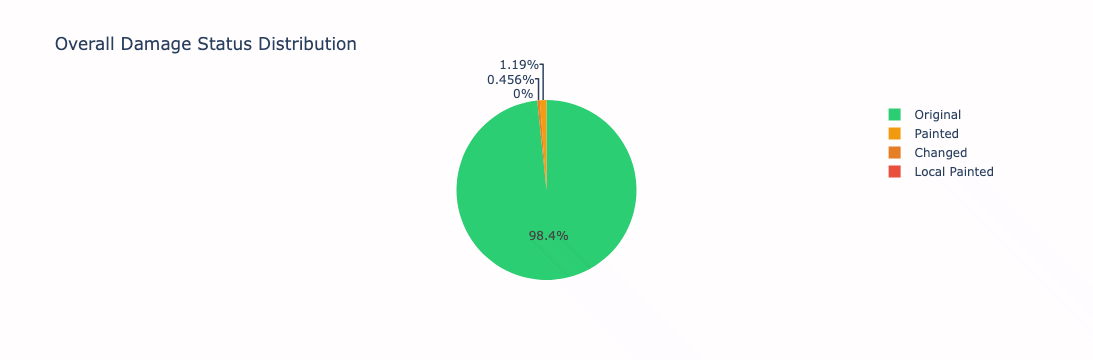

In [83]:
# Damage status distribution across all listings
damage_summary = df[["damage_original_count", "damage_painted_count",
                      "damage_local_painted_count", "damage_changed_count"]].sum()
damage_summary.index = ["Original", "Painted", "Local Painted", "Changed"]

fig = px.pie(
    values=damage_summary.values, names=damage_summary.index,
    title="Overall Damage Status Distribution",
    color_discrete_sequence=["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]
)
fig.show()

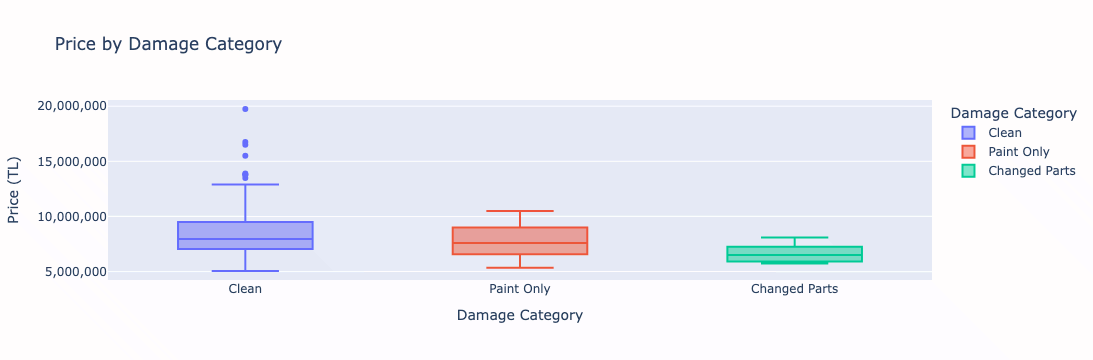

In [84]:
# Price impact of damage
df["has_damage"] = (df["damage_painted_count"].fillna(0) + df["damage_changed_count"].fillna(0)) > 0
df["damage_category"] = df.apply(
    lambda r: "Changed Parts" if (r.get("damage_changed_count") or 0) > 0
    else "Paint Only" if (r.get("damage_painted_count") or 0) + (r.get("damage_local_painted_count") or 0) > 0
    else "Clean",
    axis=1
)

fig = px.box(
    df, x="damage_category", y="price", color="damage_category",
    title="Price by Damage Category",
    labels={"price": "Price (TL)", "damage_category": "Damage Category"},
    category_orders={"damage_category": ["Clean", "Paint Only", "Changed Parts"]}
)
fig.update_layout(yaxis_tickformat=",.0f")
fig.show()

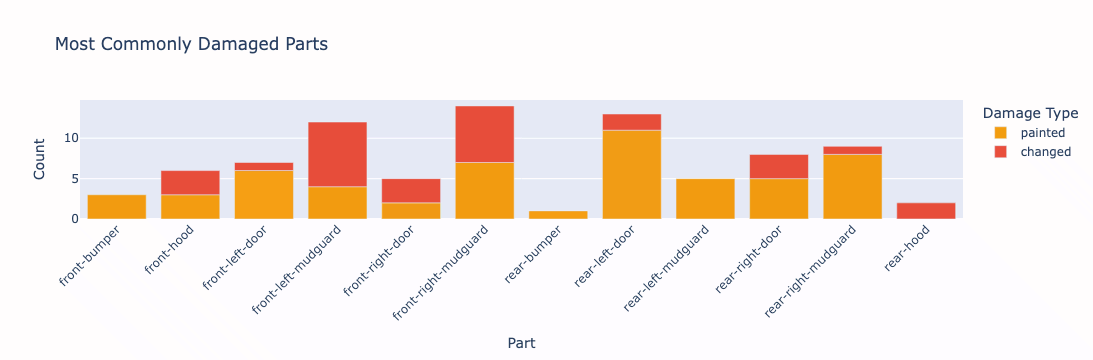

In [85]:
# Heatmap of most commonly damaged parts
if not df_damage.empty:
    damage_pivot = df_damage[df_damage["status"] != "original"].groupby(
        ["part_name", "status"]
    ).size().reset_index(name="count")

    if not damage_pivot.empty:
        fig = px.bar(
            damage_pivot, x="part_name", y="count", color="status",
            title="Most Commonly Damaged Parts",
            labels={"part_name": "Part", "count": "Count", "status": "Damage Type"},
            color_discrete_map={
                "painted": "#f39c12", "local-painted": "#e67e22", "changed": "#e74c3c"
            }
        )
        fig.update_layout(xaxis_tickangle=-45)
        fig.show()
    else:
        print("No damage data found.")
else:
    print("No damage data available.")

## Section 7: Feature Comparison

Maps out what equipment is standard vs rare in the Turkish Taycan market. The frequency table shows which features almost every car has (ABS, airbags, electric mirrors) versus genuinely rare options (head-up display, night vision, sunroof). The price correlation chart reveals which features are associated with higher-priced cars — these are the premium options that add real value. Use this to judge whether a well-equipped car at a slightly higher price is actually a better deal than a stripped-down cheaper one.

In [86]:
# Feature frequency table
if not df_features.empty:
    present_features = df_features[df_features["is_present"] == 1]
    feature_freq = present_features.groupby(["category", "feature_name"]).size().reset_index(name="count")
    feature_freq["pct"] = (feature_freq["count"] / len(df) * 100).round(1)
    feature_freq = feature_freq.sort_values("count", ascending=False)

    print("Top 20 most common features:")
    display(feature_freq.head(20))

    print("\n10 rarest features:")
    display(feature_freq.tail(10))
else:
    print("No feature data available.")

Top 20 most common features:


,category,feature_name,count,pct
13,Güvenlik,ABS,154,60.9
20,Güvenlik,Hava Yastığı (Yolcu),154,60.9
2,Dış Donanım,Aynalar (Elektrikli),153,60.5
19,Güvenlik,Hava Yastığı (Sürücü),153,60.5
24,Güvenlik,Merkezi Kilit,153,60.5
35,İç Donanım,Anahtarsız Giriş ve Çalıştırma,152,60.1
25,Güvenlik,Yokuş Kalkış Desteği,152,60.1
9,Dış Donanım,Park Sensörü (Arka),152,60.1
10,Dış Donanım,Park Sensörü (Ön),152,60.1
37,İç Donanım,Elektrikli Camlar,151,59.7



10 rarest features:


,category,feature_name,count,pct
1,Dış Donanım,Ayakla Açılan Bagaj Kapağı,43,17.0
34,İç Donanım,Adaptive Cruise Control,38,15.0
40,İç Donanım,Head-up Display,32,12.6
18,Güvenlik,Gece Görüş Sistemi,31,12.3
12,Dış Donanım,Sunroof,23,9.1
6,Dış Donanım,Hardtop,12,4.7
56,İç Donanım,Üçüncü Sıra Koltuklar,10,4.0
49,İç Donanım,Kumaş Koltuk,7,2.8
11,Dış Donanım,Römork Çeki Demiri,6,2.4
27,Güvenlik,Zırhlı Araç,4,1.6


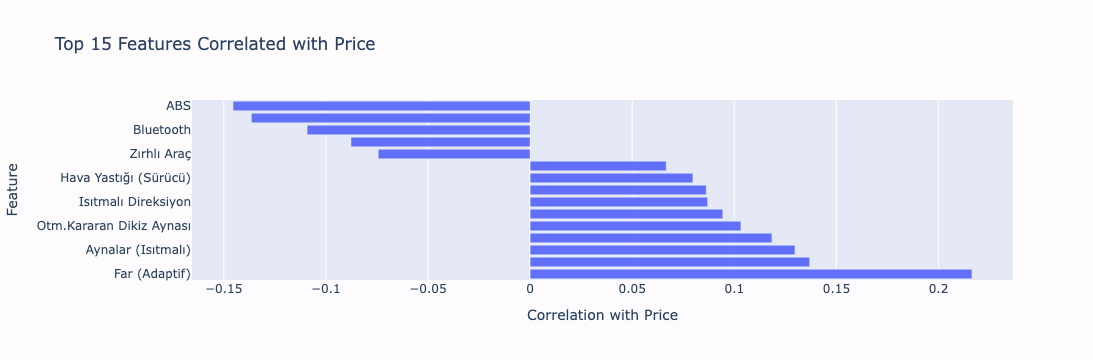

In [87]:
# Feature impact on price: correlate feature presence with price
if not df_features.empty:
    # Pivot features to wide format per listing
    feat_wide = df_features[df_features["is_present"] == 1].pivot_table(
        index="listing_id", columns="feature_name", values="is_present",
        fill_value=0, aggfunc="max"
    )

    # Merge with price
    feat_price = feat_wide.merge(df[["id", "price"]].rename(columns={"id": "listing_id"}),
                                  on="listing_id")

    # Correlate each feature with price
    correlations = feat_price.drop(columns=["listing_id"]).corr()["price"].drop("price")
    top_corr = correlations.abs().nlargest(15)
    premium_features = correlations[top_corr.index].sort_values(ascending=False)

    fig = px.bar(
        x=premium_features.values, y=premium_features.index,
        orientation="h",
        title="Top 15 Features Correlated with Price",
        labels={"x": "Correlation with Price", "y": "Feature"}
    )
    fig.show()
else:
    print("No feature data available.")

## Section 8: Depreciation Analysis

Models how Taycans lose value over time and mileage. The OLS trendlines on price-vs-year and price-vs-km show the depreciation slope for each variant. The depreciation curve plots average price by age, making it easy to see where the steepest drops happen. The sweet-spot table identifies the best model/year combinations by average value score — these are the segments where you get the most car for the least money. Critical for timing your purchase: buying right after a steep depreciation cliff maximizes value retention.

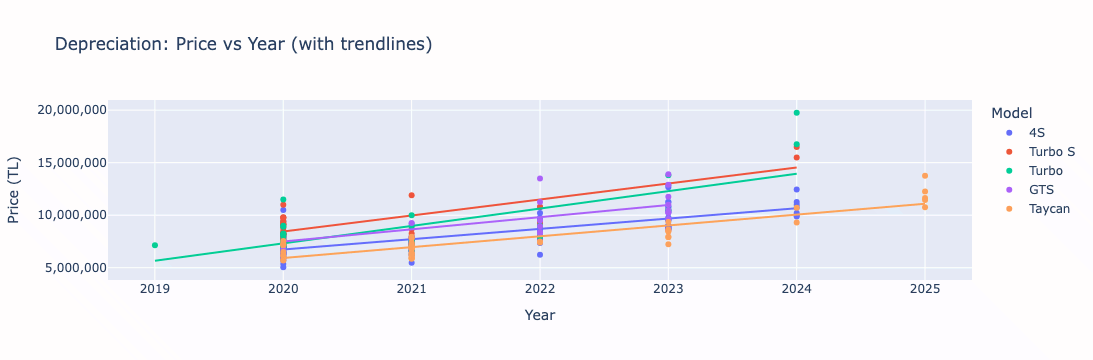

In [88]:
# Price vs Year with trendlines per model
fig = px.scatter(
    df, x="year", y="price", color="model",
    trendline="ols",
    title="Depreciation: Price vs Year (with trendlines)",
    labels={"year": "Year", "price": "Price (TL)", "model": "Model"}
)
fig.update_layout(yaxis_tickformat=",.0f")
fig.show()

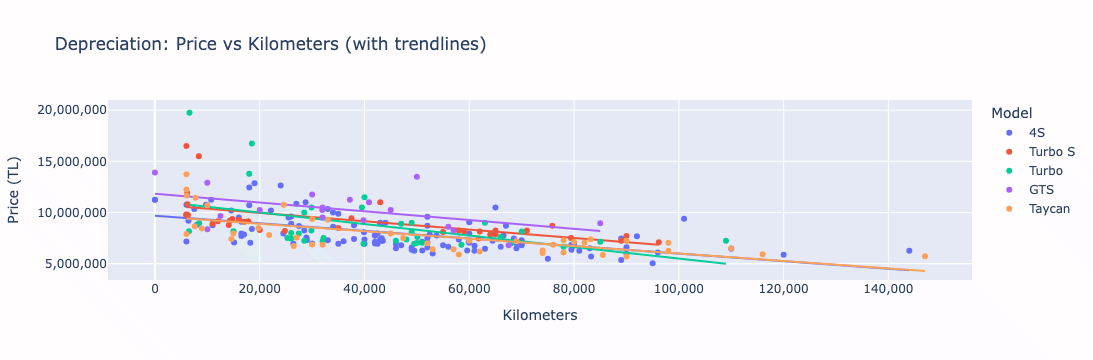

In [89]:
# Price vs KM with trendlines per model
fig = px.scatter(
    df, x="km", y="price", color="model",
    trendline="ols",
    title="Depreciation: Price vs Kilometers (with trendlines)",
    labels={"km": "Kilometers", "price": "Price (TL)", "model": "Model"}
)
fig.update_layout(xaxis_tickformat=",.0f", yaxis_tickformat=",.0f")
fig.show()

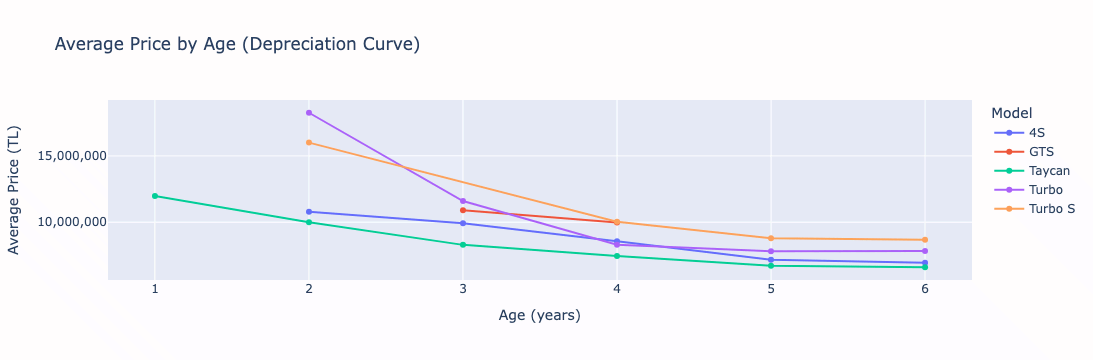

In [90]:
# Estimated annual depreciation rate
current_year = 2026
depr_data = []
for model, group in df.groupby("model"):
    if len(group) < 3:
        continue
    for year in group["year"].unique():
        subset = group[group["year"] == year]
        if len(subset) >= 2:
            avg_price = subset["price"].mean()
            age = current_year - year
            depr_data.append({"model": model, "year": year, "age": age, "avg_price": avg_price})

if depr_data:
    df_depr = pd.DataFrame(depr_data)
    fig = px.line(
        df_depr.sort_values(["model", "age"]),
        x="age", y="avg_price", color="model", markers=True,
        title="Average Price by Age (Depreciation Curve)",
        labels={"age": "Age (years)", "avg_price": "Average Price (TL)", "model": "Model"}
    )
    fig.update_layout(yaxis_tickformat=",.0f")
    fig.show()
else:
    print("Not enough data for depreciation analysis.")

In [91]:
# Sweet spot identification: best value (price/km/age combinations)
sweet = df.groupby(["model", "year"]).agg(
    avg_price=("price", "mean"),
    avg_km=("km", "mean"),
    count=("id", "count"),
    avg_value_score=("value_score", "mean")
).reset_index()
sweet = sweet[sweet["count"] >= 2].sort_values("avg_value_score", ascending=False)

print("Sweet Spots — Best Model/Year combinations by average value score:")
display(sweet.head(10).round(0))

Sweet Spots — Best Model/Year combinations by average value score:


,model,year,avg_price,avg_km,count,avg_value_score
24,Turbo S,2024,16000000.0,7188.0,2,83.0
20,Turbo,2024,18250000.0,12552.0,2,78.0
8,GTS,2023,10905000.0,27829.0,10,75.0
23,Turbo S,2022,10037500.0,11106.0,2,74.0
7,GTS,2022,9970833.0,45200.0,6,72.0
4,4S,2024,10783500.0,23804.0,7,72.0
14,Taycan,2025,11970000.0,10078.0,5,72.0
13,Taycan,2024,9999500.0,21500.0,2,71.0
19,Turbo,2023,11600000.0,29133.0,3,71.0
22,Turbo S,2021,8790000.0,60000.0,5,67.0


## Section 9: Facelift (2024+) Decision Area

Dedicated analysis for the 2024+ facelift models, which represent the strongest long-term buy. The facelift brought generational improvements that make pre-2024 cars significantly less competitive on the used market going forward. Use the summary table to compare average prices and scores across facelift variants, the bubble chart to spot pricing anomalies by model, the KM-vs-price scatter (colored by value score) to find low-mileage bargains, and the ranked decision table to shortlist your top candidates. If your budget allows a facelift model, this section should drive your final decision.

Key facelift upgrades:
- **Battery**: 93 → 105 kWh (+13%)
- **Range**: up to 678 km WLTP (+35%)
- **Charging**: 270 → 320 kW DC, 10-80% in 18 min (was 37 min)
- **Regen**: 290 → 400 kW recuperation
- **Power**: +60 to +140 kW across all variants
- **Chassis**: Air suspension now standard

In [92]:
# Filter to facelift models only (2024+)
df_fl = df[df["year"] >= 2024].copy()
print(f"Facelift listings (2024+): {len(df_fl)}")
print(f"Price range: {df_fl['price'].min():,.0f} - {df_fl['price'].max():,.0f} TL\n")

# Summary table by model
fl_summary = df_fl.groupby("model").agg(
    count=("id", "count"),
    avg_price=("price", "mean"),
    min_price=("price", "min"),
    max_price=("price", "max"),
    avg_km=("km", "mean"),
    avg_damage=("damage_penalty", "mean"),
    avg_features=("feature_count", "mean"),
    avg_value_score=("value_score", "mean"),
).round(0).sort_values("avg_value_score", ascending=False)
fl_summary.columns = ["Count", "Avg Price", "Min Price", "Max Price", "Avg KM",
                       "Avg Damage", "Avg Features", "Avg Score"]
print("Facelift Models Comparison:")
display(fl_summary)

Facelift listings (2024+): 18
Price range: 9,299,000 - 19,750,000 TL

Facelift Models Comparison:


,Count,Avg Price,Min Price,Max Price,Avg KM,Avg Damage,Avg Features,Avg Score
model,,,,,,,,
Turbo S,2,16000000.0,15500000,16500000,7188.0,0.0,24.0,83.0
Turbo,2,18250000.0,16750000,19750000,12552.0,0.0,0.0,78.0
4S,7,10783500.0,9890000,12450000,23804.0,0.0,11.0,72.0
Taycan,7,11407000.0,9299000,13750000,13342.0,0.0,31.0,71.0


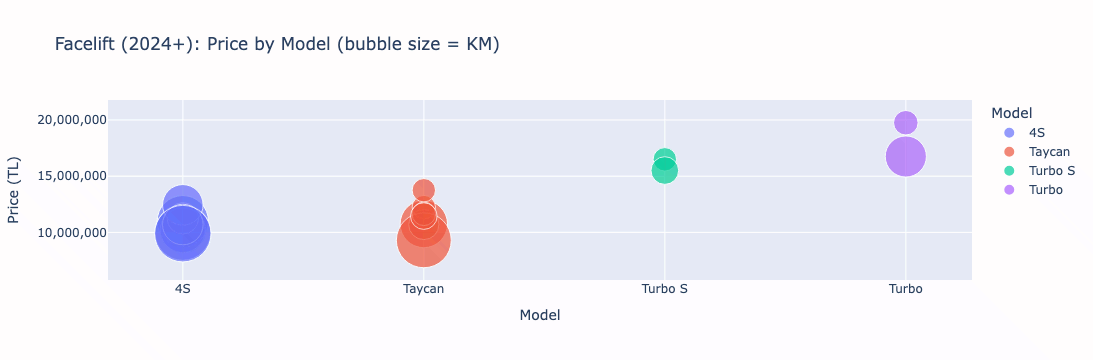

In [93]:
# Facelift: Price vs Model scatter with KM as size
if not df_fl.empty:
    fig = px.scatter(
        df_fl, x="model", y="price", size="km", color="model",
        hover_data=["sahibinden_id", "title", "km", "damage_penalty", "value_score"],
        title="Facelift (2024+): Price by Model (bubble size = KM)",
        labels={"price": "Price (TL)", "model": "Model", "km": "Kilometers"},
        size_max=40,
    )
    fig.update_layout(yaxis_tickformat=",.0f")
    fig.show()

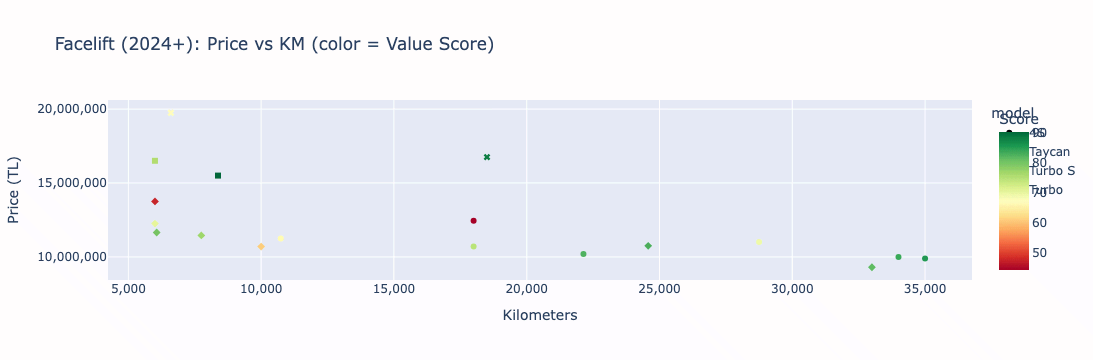

In [94]:
# Facelift: Price vs KM with value score as color
if not df_fl.empty:
    fig = px.scatter(
        df_fl, x="km", y="price", color="value_score",
        symbol="model", hover_data=["sahibinden_id", "title", "model", "damage_penalty"],
        title="Facelift (2024+): Price vs KM (color = Value Score)",
        labels={"price": "Price (TL)", "km": "Kilometers", "value_score": "Score"},
        color_continuous_scale="RdYlGn",
    )
    fig.update_layout(xaxis_tickformat=",.0f", yaxis_tickformat=",.0f")
    fig.show()

In [95]:
# Facelift: All listings ranked — decision table
if not df_fl.empty:
    fl_cols = ["sahibinden_id", "model", "year", "km", "price", "color",
               "damage_changed_count", "damage_painted_count", "heavy_damage_record",
               "feature_count", "seller_type", "value_score", "url"]
    df_fl_browse = df_fl[fl_cols].sort_values("value_score", ascending=False).reset_index(drop=True)
    df_fl_browse.index += 1

    def make_link(url):
        return f'<a href="{url}" target="_blank">Link</a>' if url else ""

    print(f"All {len(df_fl_browse)} facelift listings ranked by value score:")
    styled = df_fl_browse.style.format({
        "url": make_link, "price": "{:,.0f}", "km": "{:,.0f}",
        "feature_count": "{:.0f}", "value_score": "{:.1f}"
    }).background_gradient(subset=["value_score"], cmap="RdYlGn")
    display(HTML(styled.to_html(escape=False)))
else:
    print("No facelift (2024+) listings found.")

All 18 facelift listings ranked by value score:


,sahibinden_id,model,year,km,price,color,damage_changed_count,damage_painted_count,heavy_damage_record,feature_count,seller_type,value_score,url
1,1281103381,Turbo S,2024,"8,375","15,500,000",Siyah,0,0,Hayır,0,Galeriden,90.3,Link
2,1285704385,Turbo,2024,"18,504","16,750,000",Siyah,0,0,Hayır,0,Galeriden,88.4,Link
3,1298214368,4S,2024,"35,000","9,890,000",Beyaz,0,0,Hayır,0,Galeriden,85.4,Link
4,1294167284,4S,2024,"34,000","9,995,500",Füme,0,0,Hayır,0,Galeriden,83.7,Link
5,1256562215,Taycan,2025,"24,575","10,750,000",Gri,0,0,Hayır,32,Galeriden,82.8,Link
6,1278822187,4S,2024,"22,137","10,200,000",Gri,0,0,Hayır,0,Galeriden,82.6,Link
7,1279215406,Taycan,2024,"33,000","9,299,000",Siyah,0,0,Hayır,42,Galeriden,81.5,Link
8,1293347439,Taycan,2025,"6,066","11,650,000",Siyah,0,0,Hayır,49,Yetkili Bayiden,80.1,Link
9,1294311274,Taycan,2025,"7,747","11,450,000",Siyah,0,0,Hayır,0,Galeriden,76.9,Link
10,1280431006,Turbo S,2024,"6,001","16,500,000",Gri,0,0,Hayır,48,Galeriden,75.4,Link


## Section 10: Top Candidates

A single ranked list of the 15 highest value-scored listings, each annotated with auto-generated reasoning and buyer-profile tags. Instead of two separate filtered tables ("Safest Investment" / "Best Value"), this unified view explains *why* each car ranks well — citing specific numbers like km/year, price vs market average, and damage status. Two tags help quick scanning:

- **SAFE** — Clean (hatasız), 2023+, low-km: the lowest-risk picks
- **VALUE** — No high-km risk, minimal damage: best price-performance ratio

The same 15 cars and their reasoning feed directly into the AI prompt in Section 11.

In [96]:
# --- Top 15 Candidates with auto-generated reasoning ---
top_candidates = df.nlargest(15, "value_score").copy()

# Buyer-profile tags
top_candidates["safe_pick"] = (
    top_candidates["is_clean"] &
    (top_candidates["year"] >= 2023) &
    (top_candidates["km_per_year"].fillna(99999) <= 15000)
)
top_candidates["value_pick"] = (
    ~top_candidates["risk_high_km"] &
    (top_candidates["damage_changed_count"].fillna(0) <= 1)
)

# Median price of all eligible listings (for "below market" reasoning)
median_price_all = df["price"].median()
# 75th percentile of feature counts
feature_p75 = df["feature_count"].quantile(0.75)
# 25th percentile of price
price_p25 = df["price"].quantile(0.25)

def build_reason(row, df_all=df):
    """Build a compelling 2-3 snippet reason string for a candidate."""
    snippets = []

    # 1. Flagship at below-market price
    if row["model"] in ("Turbo S", "GTS") and row["price"] < median_price_all:
        pct_below = (1 - row["price"] / median_price_all) * 100
        snippets.append(f"Flagship {row['model']} at {pct_below:.0f}% below market median")

    # 2. Barely driven
    km_yr = row.get("km_per_year")
    if pd.notna(km_yr) and km_yr < 5000:
        snippets.append(f"Barely driven ({km_yr:,.0f} km/yr)")
    elif pd.notna(km_yr) and km_yr < 10000:
        snippets.append(f"Low usage ({km_yr:,.0f} km/yr)")

    # 3. Clean + bayi combo
    if row["is_clean"] and row["is_bayi"]:
        snippets.append("Zero damage + dealer origin (warranty intact)")
    elif row["is_clean"]:
        snippets.append("Zero damage history (hatasız)")

    # 4. Budget entry
    if row["price"] <= price_p25:
        snippets.append(f"Budget entry at {row['price']:,.0f} TL")

    # 5. Facelift model
    if row["year"] >= 2024:
        snippets.append("Facelift model (bigger battery, faster charging)")

    # 6. Recent + clean
    if row["year"] >= 2023 and row["is_clean"] and "Zero damage" not in " ".join(snippets):
        snippets.append("Recent model year, spotless condition")

    # 7. Well-equipped
    if row["feature_count"] > feature_p75:
        snippets.append(f"Well-equipped ({int(row['feature_count'])} features)")

    # 8. Premium trim (only if not already mentioned via flagship)
    if row["model"] in ("Turbo S", "GTS", "Turbo") and not any("Flagship" in s for s in snippets):
        snippets.append(f"Premium {row['model']} trim — strong resale")

    # Take the top 2-3 most compelling
    return " · ".join(snippets[:3]) if snippets else "Strong composite value score"

top_candidates["reason"] = top_candidates.apply(build_reason, axis=1)

# Build tags column
def format_tags(row):
    tags = []
    if row["safe_pick"]:
        tags.append("SAFE")
    if row["value_pick"]:
        tags.append("VALUE")
    return ", ".join(tags) if tags else "—"

top_candidates["tags"] = top_candidates.apply(format_tags, axis=1)

# Display table
display_cols = ["model", "year", "km", "price", "reason", "tags", "value_score", "url"]
tc_display = top_candidates[display_cols].reset_index(drop=True)
tc_display.index += 1
tc_display.index.name = "Rank"

def make_link(url):
    return f'<a href="{url}" target="_blank">Link</a>' if url else ""

def highlight_tags(val):
    if "SAFE" in str(val) and "VALUE" in str(val):
        return "background-color: #d4edda; font-weight: bold"
    elif "SAFE" in str(val):
        return "background-color: #cce5ff; font-weight: bold"
    elif "VALUE" in str(val):
        return "background-color: #fff3cd; font-weight: bold"
    return ""

styled = (
    tc_display.style
    .format({
        "price": "{:,.0f}", "km": "{:,.0f}",
        "value_score": "{:.1f}", "url": make_link
    })
    .map(highlight_tags, subset=["tags"])
    .background_gradient(subset=["value_score"], cmap="RdYlGn")
    .set_properties(subset=["reason"], **{"max-width": "400px", "white-space": "normal"})
)

print(f"Top 15 Candidates (from {len(df)} eligible listings):\n")
display(HTML(styled.to_html(escape=False)))

Top 15 Candidates (from 253 eligible listings):



,model,year,km,price,reason,tags,value_score,url
Rank,,,,,,,,
1,GTS,2023,"56,000","8,600,000",Zero damage + dealer origin (warranty intact) · Well-equipped (43 features) · Premium GTS trim — strong resale,VALUE,100.0,Link
2,GTS,2023,"12,500","9,650,000","Barely driven (4,167 km/yr) · Zero damage + dealer origin (warranty intact) · Well-equipped (50 features)","SAFE, VALUE",95.8,Link
3,4S,2021,"75,000","5,490,000","Budget entry at 5,490,000 TL · Well-equipped (52 features)",VALUE,94.9,Link
4,Turbo S,2024,"8,375","15,500,000","Barely driven (4,188 km/yr) · Zero damage history (hatasız) · Facelift model (bigger battery, faster charging)","SAFE, VALUE",90.3,Link
5,4S,2020,"95,000","5,050,000","Zero damage + dealer origin (warranty intact) · Budget entry at 5,050,000 TL",VALUE,89.5,Link
6,Turbo,2024,"18,504","16,750,000","Low usage (9,252 km/yr) · Zero damage + dealer origin (warranty intact) · Facelift model (bigger battery, faster charging)","SAFE, VALUE",88.4,Link
7,GTS,2022,"10,000","8,375,000","Barely driven (2,500 km/yr) · Zero damage history (hatasız) · Premium GTS trim — strong resale",VALUE,87.3,Link
8,Turbo S,2022,"16,000","9,275,000","Barely driven (4,000 km/yr) · Zero damage + dealer origin (warranty intact) · Premium Turbo S trim — strong resale",VALUE,86.9,Link
9,Turbo S,2020,"96,176","7,100,000",Flagship Turbo S at 10% below market median,VALUE,86.8,Link


## Section 11: AI-Powered Recommendation

Generates a ready-to-paste prompt using the **same 15 candidates** from Section 10, including their auto-generated reasoning and buyer-profile tags. Each car comes with data-driven context (e.g. "Flagship Turbo S at 18% below market median · Barely driven · Zero damage + dealer origin") so the AI starts from an informed position rather than raw numbers. Copy this into Claude, ChatGPT, or any LLM to get a second opinion with personalized trade-off analysis.

In [98]:
# AI prompt using the same top 15 candidates from Section 10
prompt_lines = [
    "I'm looking to buy a used Porsche Taycan in Turkey. Below are the top 15 candidates",
    "from sahibinden.com ranked by a composite value score. Each car has a data-driven",
    "reason for its ranking plus buyer-profile tags ([SAFE] = low-risk pick,",
    "[VALUE] = best price-performance). Use these as starting context but apply your own",
    "judgment to recommend the top 3 picks with detailed reasoning.\n",
    "IMPORTANT CONTEXT:",
    "- Cars with heavy damage records (Ağır Hasar Kaydı: Evet) have been pre-filtered out",
    "- Cars with 3+ changed body parts have been pre-filtered out",
    "- Cars from 2023+ with any changed parts have been pre-filtered out",
    "- 'is_clean' means zero painted/changed parts (hatasız)",
    "- 'is_bayi' means authorized dealer (Doğuş/Porsche) origin detected in listing",
    "- 2024+ models are 'facelift' with bigger battery (105 kWh), faster charging (320 kW), more power\n",
    "Consider: price fairness, km_per_year (usage intensity), damage history,",
    "model variant desirability, clean/bayi status, risk flags, and overall value.\n",
    "Candidates:\n"
]

for i, (_, row) in enumerate(top_candidates.iterrows(), 1):
    features_for_listing = df_features[
        (df_features["listing_id"] == row["id"]) & (df_features["is_present"] == 1)
    ]["feature_name"].tolist()
    top_features = ", ".join(features_for_listing[:15])

    km_yr = f"{row['km_per_year']:,.0f}" if pd.notna(row.get("km_per_year")) else "N/A"
    risks = []
    if row.get("risk_high_km"): risks.append("high-km")
    if row.get("risk_many_painted"): risks.append("many-painted")
    if row.get("risk_gallery_unknown"): risks.append("gallery-unknown-damage")
    risk_str = ", ".join(risks) if risks else "none"

    # Tags
    tags = []
    if row.get("safe_pick"): tags.append("[SAFE]")
    if row.get("value_pick"): tags.append("[VALUE]")
    tag_str = " ".join(tags) if tags else ""

    prompt_lines.append(f"""#{i} {tag_str} — {row['title']}
  URL: {row['url']}
  Model: {row['model']} | Year: {row['year']} | KM: {row['km']:,.0f} | KM/year: {km_yr}
  Price: {row['price']:,.0f} TL | Seller: {row.get('seller_type', 'N/A')}
  Damage: {int(row.get('damage_changed_count', 0) or 0)} changed, {int(row.get('damage_painted_count', 0) or 0)} painted, {int(row.get('damage_local_painted_count', 0) or 0)} local-painted
  Clean (hatasız): {row.get('is_clean', False)} | Bayi çıkışlı: {row.get('is_bayi', False)}
  Risk flags: {risk_str}
  Features: {top_features}
  Value Score: {row['value_score']}/100
  Why it ranks: {row['reason']}
""")

ai_prompt = "\n".join(prompt_lines)
print(ai_prompt)

I'm looking to buy a used Porsche Taycan in Turkey. Below are the top 15 candidates
from sahibinden.com ranked by a composite value score. Each car has a data-driven
reason for its ranking plus buyer-profile tags ([SAFE] = low-risk pick,
[VALUE] = best price-performance). Use these as starting context but apply your own
judgment to recommend the top 3 picks with detailed reasoning.

IMPORTANT CONTEXT:
- Cars with heavy damage records (Ağır Hasar Kaydı: Evet) have been pre-filtered out
- Cars with 3+ changed body parts have been pre-filtered out
- Cars from 2023+ with any changed parts have been pre-filtered out
- 'is_clean' means zero painted/changed parts (hatasız)
- 'is_bayi' means authorized dealer (Doğuş/Porsche) origin detected in listing
- 2024+ models are 'facelift' with bigger battery (105 kWh), faster charging (320 kW), more power

Consider: price fairness, km_per_year (usage intensity), damage history,
model variant desirability, clean/bayi status, risk flags, and overall val

## Section 12: Interactive Listing Browser

A full sortable table of every eligible listing plus a dropdown detail viewer. The table lets you sort by any column — price, value score, damage, mileage — to quickly scan the entire market. Click any listing's link to open it on sahibinden.com. The dropdown below shows a detailed card for each listing including all specs, damage breakdown, features, and seller info. Use this as your final reference when narrowing down to 3-5 cars to contact sellers about.

In [99]:
# Interactive sortable table (with new metrics)
browse_cols = [
    "sahibinden_id", "model", "year", "km", "km_per_year", "price", "color",
    "location_city", "damage_changed_count", "damage_painted_count",
    "is_clean", "is_bayi", "seller_type", "value_score", "url"
]

df_browse = df[browse_cols].sort_values("value_score", ascending=False).reset_index(drop=True)
df_browse.index += 1

def make_clickable(url):
    if url:
        return f'<a href="{url}" target="_blank">Link</a>'
    return ""

styled = df_browse.style.format({
    "url": make_clickable, "price": "{:,.0f}", "km": "{:,.0f}",
    "km_per_year": "{:,.0f}", "value_score": "{:.1f}"
})
display(HTML(styled.to_html(escape=False)))

,sahibinden_id,model,year,km,km_per_year,price,color,location_city,damage_changed_count,damage_painted_count,is_clean,is_bayi,seller_type,value_score,url
1,1294179544,GTS,2023,"56,000","18,667","8,600,000",Siyah,İstanbul,0,0,True,True,Galeriden,100.0,Link
2,1285513217,GTS,2023,"12,500","4,167","9,650,000",Siyah,İstanbul,0,0,True,True,Sahibinden,95.8,Link
3,1285887345,4S,2021,"75,000","15,000","5,490,000",Siyah,İzmir,0,1,False,True,Galeriden,94.9,Link
4,1281103381,Turbo S,2024,"8,375","4,188","15,500,000",Siyah,Gaziantep,0,0,True,False,Galeriden,90.3,Link
5,1295622327,4S,2020,"95,000","15,833","5,050,000",Füme,Şanlıurfa,0,0,True,True,Galeriden,89.5,Link
6,1285704385,Turbo,2024,"18,504","9,252","16,750,000",Siyah,İstanbul,0,0,True,True,Galeriden,88.4,Link
7,1262362687,GTS,2022,"10,000","2,500","8,375,000",Gri,İstanbul,0,0,True,False,Galeriden,87.3,Link
8,1298727668,Turbo S,2022,"16,000","4,000","9,275,000",Siyah,İstanbul,0,0,True,True,Galeriden,86.9,Link
9,1286633466,Turbo S,2020,"96,176","16,029","7,100,000",Lacivert,İstanbul,0,1,False,True,Galeriden,86.8,Link
10,1232719997,GTS,2022,"57,000","14,250","8,250,000",Bordo,Konya,0,0,True,True,Galeriden,85.9,Link


In [100]:
def show_listing(sahibinden_id):
    """Display a detailed card for a listing."""
    row = df[df["sahibinden_id"] == sahibinden_id]
    if row.empty:
        row = df_disqualified[df_disqualified["sahibinden_id"] == sahibinden_id]
        if row.empty:
            print(f"Listing {sahibinden_id} not found.")
            return
    row = row.iloc[0]

    # Get damage parts
    parts = df_damage[df_damage["listing_id"] == row["id"]]
    damaged_parts = parts[parts["status"] != "original"]

    # Get features
    feats = df_features[
        (df_features["listing_id"] == row["id"]) & (df_features["is_present"] == 1)
    ]["feature_name"].tolist()

    km_yr = f"{row['km_per_year']:,.0f}/yr" if pd.notna(row.get("km_per_year")) else "N/A"
    is_clean = row.get("is_clean", False)
    is_bayi = row.get("is_bayi", False)

    html = f"""
    <div style="border:2px solid #333; border-radius:10px; padding:20px; max-width:700px;
                font-family:sans-serif; background:#fafafa;">
        <h3 style="margin:0 0 10px 0;">{row['title']}</h3>
        <div style="display:grid; grid-template-columns:1fr 1fr; gap:8px; font-size:14px;">
            <div><b>Model:</b> {row['model']}</div>
            <div><b>Year:</b> {row['year']}</div>
            <div><b>KM:</b> {row['km']:,.0f} ({km_yr})</div>
            <div><b>Price:</b> {row['price']:,.0f} TL</div>
            <div><b>Color:</b> {row.get('color', 'N/A')}</div>
            <div><b>Location:</b> {row.get('location_city', 'N/A')}</div>
            <div><b>Seller:</b> {row.get('seller_type', 'N/A')} \u2014 {row.get('seller_name', 'N/A')}</div>
            <div><b>Heavy Damage:</b> {row.get('heavy_damage_record', 'N/A')}</div>
            <div><b>Clean (hatas\u0131z):</b> {'Yes' if is_clean else 'No'}</div>
            <div><b>Bayi \u00e7\u0131k\u0131\u015fl\u0131:</b> {'Yes' if is_bayi else 'No'}</div>
            <div><b>Value Score:</b> {row.get('value_score', 'N/A')}/100</div>
            <div><b>Body Type:</b> {row.get('body_type', 'N/A')}</div>
        </div>
    """

    if not damaged_parts.empty:
        html += '<h4 style="margin:15px 0 5px 0;">Damaged Parts:</h4><ul style="margin:0;">'
        for _, p in damaged_parts.iterrows():
            color = {"painted": "#f39c12", "local-painted": "#e67e22", "changed": "#e74c3c"}.get(p["status"], "#999")
            html += f'<li><span style="color:{color};font-weight:bold;">{p["status"]}</span>: {p["part_name"]}</li>'
        html += "</ul>"
    else:
        html += '<p style="color:#2ecc71;font-weight:bold;margin:10px 0;">No damaged parts (hatas\u0131z)</p>'

    if feats:
        html += f'<h4 style="margin:15px 0 5px 0;">Features ({len(feats)}):</h4>'
        html += '<p style="font-size:13px;line-height:1.6;">' + ", ".join(feats) + "</p>"

    url = row.get("url", "")
    if url:
        html += f'<a href="{url}" target="_blank" style="display:inline-block;margin-top:10px;padding:8px 16px;background:#333;color:#fff;border-radius:5px;text-decoration:none;">View on Sahibinden</a>'

    html += "</div>"
    display(HTML(html))

In [101]:
# Interactive dropdown to browse listings
options = [
    f"{row['sahibinden_id']} — {row['model']} {row['year']} — {row['price']:,.0f} TL — Score: {row['value_score']}"
    for _, row in df.sort_values("value_score", ascending=False).iterrows()
]
sah_ids = df.sort_values("value_score", ascending=False)["sahibinden_id"].tolist()

dropdown = widgets.Dropdown(options=list(zip(options, sah_ids)), description="Listing:")
output = widgets.Output()

def on_select(change):
    output.clear_output()
    with output:
        show_listing(change["new"])

dropdown.observe(on_select, names="value")
display(dropdown, output)

# Trigger initial display
if sah_ids:
    with output:
        show_listing(sah_ids[0])

Dropdown(description='Listing:', options=(('1294179544 — GTS 2023 — 8,600,000 TL — Score: 100.0', '1294179544'…

Output()